In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import joblib



In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df = df[['petal length (cm)', 'petal width (cm)']]

print(df.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


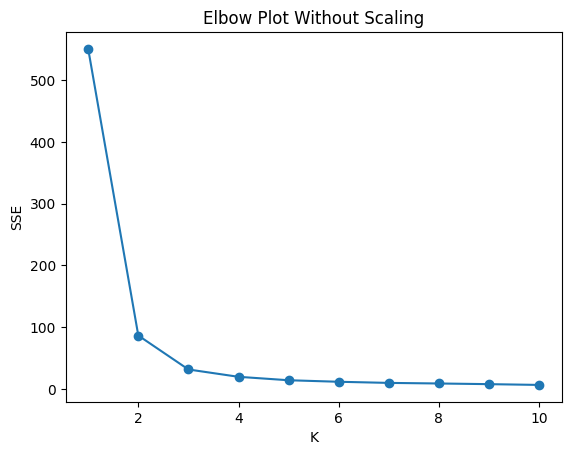

In [3]:
sse = []

k_rng = range(1, 11)

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df)
    sse.append(km.inertia_)


plt.plot(k_rng, sse, marker='o')
plt.xlabel("K")
plt.ylabel("SSE")
plt.title("Elbow Plot Without Scaling")
plt.show()

In [4]:
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

print(df_scaled[:5])

[[0.06779661 0.04166667]
 [0.06779661 0.04166667]
 [0.05084746 0.04166667]
 [0.08474576 0.04166667]
 [0.06779661 0.04166667]]


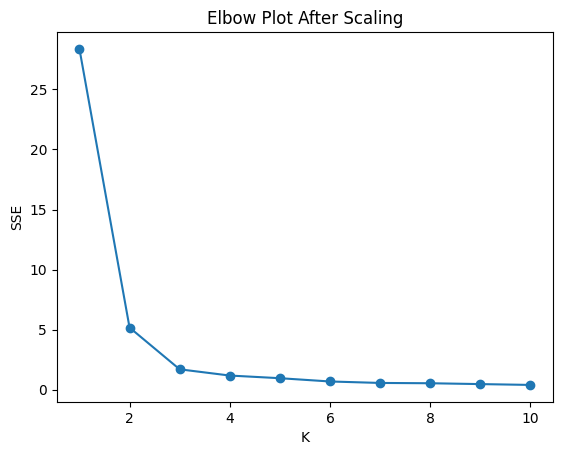

In [5]:
sse = []

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    sse.append(km.inertia_)

plt.plot(k_rng, sse, marker='o')
plt.xlabel("K")
plt.ylabel("SSE")
plt.title("Elbow Plot After Scaling")
plt.show()

In [6]:
model = KMeans(n_clusters=3, random_state=42)

model.fit(df_scaled)


clusters = model.predict(df_scaled)


df['cluster'] = clusters

print(df.head())

   petal length (cm)  petal width (cm)  cluster
0                1.4               0.2        1
1                1.4               0.2        1
2                1.3               0.2        1
3                1.5               0.2        1
4                1.4               0.2        1


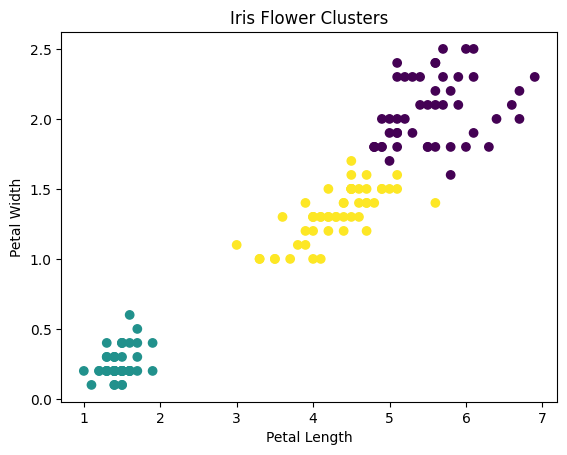

In [7]:
plt.scatter(
    df['petal length (cm)'],
    df['petal width (cm)'],
    c=df['cluster']
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Flower Clusters")
plt.show()

In [9]:
joblib.dump(model, "iris_kmeans_model.pkl")


joblib.dump(scaler, "iris_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [10]:
loaded_model = joblib.load("iris_kmeans_model.pkl")

loaded_scaler = joblib.load("iris_scaler.pkl")

In [11]:
sample = [[5.1, 1.8]]


sample_scaled = loaded_scaler.transform(sample)


prediction = loaded_model.predict(sample_scaled)

print("Cluster:", prediction[0])

Cluster: 0


c:\Users\DELL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
